# Transfer Learning Diagnostics And Improved Fine-Tuning

This notebook restructures the experiment around the main risks in the earlier setup:

- compare against simple baselines on the same fixed test set
- inspect source vs target distribution mismatch
- stop using source-fitted target scaling for training
- replace the old output layer with a new LIME-specific head
- use an adapter layer before the pretrained backbone
- use bounded output with `sigmoid` and `Huber` loss
- report fold mean and standard deviation for validation and test metrics

## 1. Imports And Configuration

In [11]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

SEED = 42
tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)

# Source model input feature names.
SOURCE_FEATURE_COLS = [
    "tADS",
    "PL",
    "v0",
    "t_press",
    "t_depress",
    "h2o_ppmv",
    "sox_ppmv",
    "nox_ppmv",
    "dust_mg_Nm3",
    "co2_mol_frac",
    "capacity_factor",
    "affinity_factor_co2",
    "mtc_factor",
    "dax_factor",
    "deactivation_index",
]

# Raw LIME-side features fed into the adapter and target-only models.
TARGET_INPUT_COLS = [
    "tADS",
    "PL",
    "v0",
    "t_press",
    "t_depress",
    "h2o_ppmv_residual",
    "sox_ppmv_residual",
    "nox_ppmv_residual",
    "dust_mg_Nm3_residual",
    "co2_mol_frac_dry",
    "capacity_factor",
    "affinity_factor_co2",
    "mtc_factor",
    "dax_factor",
    "deactivation_index",
]

# Proxy mapping is used only for source-target distribution diagnostics.
PROXY_FEATURE_MAP = {
    "tADS": "tADS",
    "PL": "PL",
    "v0": "v0",
    "t_press": "t_press",
    "t_depress": "t_depress",
    "h2o_ppmv": "h2o_ppmv_residual",
    "sox_ppmv": "sox_ppmv_residual",
    "nox_ppmv": "nox_ppmv_residual",
    "dust_mg_Nm3": "dust_mg_Nm3_residual",
    "co2_mol_frac": "co2_mol_frac_dry",
    "capacity_factor": "capacity_factor",
    "affinity_factor_co2": "affinity_factor_co2",
    "mtc_factor": "mtc_factor",
    "dax_factor": "dax_factor",
    "deactivation_index": "deactivation_index",
}

RISKY_PROXY_COLS = [
    "h2o_ppmv_residual",
    "sox_ppmv_residual",
    "nox_ppmv_residual",
    "dust_mg_Nm3_residual",
    "co2_mol_frac_dry",
]

TARGET_CONFIG = {
    "CO2_purity": "CO2_purity_dnn.keras",
    "CO2_recovery": "CO2_recovery_dnn.keras",
}

MODEL_LABELS = {
    "mean_baseline": "Mean Baseline",
    "ridge_baseline": "Target-only Ridge",
    "target_only_mlp": "Target-only MLP",
    "transfer_model": "Transfer + Adapter",
}


def resolve_root_dir() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "mof").exists():
        return cwd
    if cwd.name == "exp" and cwd.parent.name == "mof":
        return cwd.parents[1]
    if cwd.name == "mof":
        return cwd.parent
    raise RuntimeError(f"Could not resolve repository root from: {cwd}")


ROOT_DIR = resolve_root_dir()
MOF_DIR = ROOT_DIR / "mof"
DATASET_DIR = MOF_DIR / "dataset"
MODEL_DIR = MOF_DIR / "model"
OUTPUT_DIR = MOF_DIR / "exp" / "artifacts_lime_transfer_improved"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

ROOT_DIR: C:\Users\junhyun111\Desktop\psa
OUTPUT_DIR: C:\Users\junhyun111\Desktop\psa\mof\exp\artifacts_lime_transfer_improved


## 2. Data, Metrics, And Utility Functions

In [12]:
def load_source_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "Unnamed: 0" in df.columns:
        df = df.drop(columns=["Unnamed: 0"])

    required = SOURCE_FEATURE_COLS + list(TARGET_CONFIG.keys())
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing source columns: {missing}")

    return df.dropna(subset=required).reset_index(drop=True)


def load_lime_dataset(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    required = TARGET_INPUT_COLS + list(TARGET_CONFIG.keys())
    missing = [col for col in required if col not in df.columns]
    if missing:
        raise ValueError(f"Missing LIME columns: {missing}")

    if "valid_physics" in df.columns:
        df = df[df["valid_physics"] == True].copy()
    if "status" in df.columns:
        df = df[df["status"] == "ok"].copy()

    return df.dropna(subset=required).reset_index(drop=True)


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    mae = float(mean_absolute_error(y_true, y_pred))
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    denom = float(np.max(y_true) - np.min(y_true)) + 1e-8
    return {
        "mae": mae,
        "rmse": rmse,
        "r2": float(r2_score(y_true, y_pred)),
        "nmae_range": float(mae / denom),
    }


def build_distribution_table(source_df: pd.DataFrame, target_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for source_col, target_col in PROXY_FEATURE_MAP.items():
        source_values = source_df[source_col].astype(float)
        target_values = target_df[target_col].astype(float)
        source_mean = float(source_values.mean())
        source_std = float(source_values.std(ddof=0)) + 1e-8
        target_mean = float(target_values.mean())

        rows.append(
            {
                "source_feature": source_col,
                "target_feature": target_col,
                "source_mean": source_mean,
                "source_std": source_std,
                "source_min": float(source_values.min()),
                "source_max": float(source_values.max()),
                "target_mean": target_mean,
                "target_std": float(target_values.std(ddof=0)),
                "target_min": float(target_values.min()),
                "target_max": float(target_values.max()),
                "mean_shift_z": float((target_mean - source_mean) / source_std),
                "target_min_z": float((target_values.min() - source_mean) / source_std),
                "target_max_z": float((target_values.max() - source_mean) / source_std),
                "risky_proxy": target_col in RISKY_PROXY_COLS,
            }
        )

    return pd.DataFrame(rows).sort_values("mean_shift_z", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)


def make_prediction_frame(base_df: pd.DataFrame, target_col: str, y_pred: np.ndarray) -> pd.DataFrame:
    pred_df = base_df[["sample_id", target_col]].copy()
    pred_df[f"pred_{target_col}"] = y_pred
    pred_df[f"error_{target_col}"] = pred_df[f"pred_{target_col}"] - pred_df[target_col]
    return pred_df


## 3. Model Builders

The transfer model now uses:

- train-fold scaler fitted on LIME inputs only
- adapter layer before the pretrained backbone
- old output layer removed
- new LIME-specific regression head
- bounded output with `sigmoid`
- `Huber` loss instead of `MSE`

In [13]:
def make_callbacks() -> list[tf.keras.callbacks.Callback]:
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_mae",
            patience=20,
            restore_best_weights=True,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_mae",
            factor=0.5,
            patience=8,
            min_lr=1e-5,
        ),
    ]


def compile_regression_model(model: tf.keras.Model, learning_rate: float) -> tf.keras.Model:
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss=tf.keras.losses.Huber(delta=0.05),
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        ],
    )
    return model


def clone_pretrained_backbone(model_path: Path) -> tf.keras.Model:
    pretrained = tf.keras.models.load_model(model_path)
    feature_extractor = tf.keras.Model(
        inputs=pretrained.inputs,
        outputs=pretrained.layers[-2].output,
        name="pretrained_feature_extractor",
    )
    backbone = tf.keras.models.clone_model(feature_extractor)
    backbone.set_weights(feature_extractor.get_weights())
    return backbone


def set_backbone_trainability(backbone: tf.keras.Model, mode: str) -> None:
    for layer in backbone.layers:
        layer.trainable = False

    weighted_layers = [layer for layer in backbone.layers if layer.weights]
    if mode == "frozen":
        return
    if mode == "last_block":
        for layer in weighted_layers[-1:]:
            layer.trainable = True
        return
    if mode == "all":
        for layer in weighted_layers:
            layer.trainable = True
        return
    raise ValueError(f"Unknown trainability mode: {mode}")


def build_target_only_mlp(n_features: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(n_features,), name="lime_input")
    x = tf.keras.layers.Dense(32, activation="relu", name="target_dense_1")(inputs)
    x = tf.keras.layers.Dropout(0.10, name="target_dropout_1")(x)
    x = tf.keras.layers.Dense(16, activation="relu", name="target_dense_2")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="target_output")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="target_only_mlp")


def build_transfer_model(model_path: Path, n_target_features: int, n_source_features: int) -> tuple[tf.keras.Model, tf.keras.Model]:
    backbone = clone_pretrained_backbone(model_path)

    inputs = tf.keras.Input(shape=(n_target_features,), name="lime_input")
    x = tf.keras.layers.Dense(32, activation="relu", name="adapter_dense")(inputs)
    x = tf.keras.layers.Dropout(0.10, name="adapter_dropout")(x)
    x = tf.keras.layers.Dense(n_source_features, activation="linear", name="adapter_projection")(x)
    x = backbone(x)
    x = tf.keras.layers.Dense(32, activation="relu", name="lime_head_dense")(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid", name="lime_output")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="transfer_with_adapter")
    return model, backbone


def fit_target_only_model(
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
) -> tuple[tf.keras.Model, dict[str, dict[str, list[float]]]]:
    model = build_target_only_mlp(x_train.shape[1])
    compile_regression_model(model, learning_rate=1e-3)
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        epochs=120,
        batch_size=16,
        verbose=0,
        callbacks=make_callbacks(),
    )
    stage_histories = {"target_only": {k: [float(v) for v in values] for k, values in history.history.items()}}
    return model, stage_histories


def fit_transfer_model(
    model_path: Path,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
) -> tuple[tf.keras.Model, dict[str, dict[str, list[float]]]]:
    model, backbone = build_transfer_model(
        model_path=model_path,
        n_target_features=x_train.shape[1],
        n_source_features=len(SOURCE_FEATURE_COLS),
    )

    stage_plan = [
        ("stage1_frozen", "frozen", 1e-3, 120),
        ("stage2_last_block", "last_block", 3e-4, 80),
        ("stage3_all", "all", 1e-4, 60),
    ]
    stage_histories: dict[str, dict[str, list[float]]] = {}

    for stage_name, mode, learning_rate, epochs in stage_plan:
        set_backbone_trainability(backbone, mode)
        compile_regression_model(model, learning_rate=learning_rate)

        history = model.fit(
            x_train,
            y_train,
            validation_data=(x_val, y_val),
            epochs=epochs,
            batch_size=16,
            verbose=0,
            callbacks=make_callbacks(),
        )
        stage_histories[stage_name] = {k: [float(v) for v in values] for k, values in history.history.items()}

    return model, stage_histories


def predict_with_model(model: tf.keras.Model, x: np.ndarray) -> np.ndarray:
    return model.predict(x, verbose=0).reshape(-1)


## 4. Plotting Functions

In [14]:
def plot_distribution_shift(distribution_df: pd.DataFrame) -> None:
    plot_df = distribution_df.sort_values("mean_shift_z", key=lambda s: s.abs(), ascending=True)
    colors = ["#C44E52" if flag else "#4C72B0" for flag in plot_df["risky_proxy"]]

    plt.figure(figsize=(9, 7))
    plt.barh(plot_df["target_feature"], plot_df["mean_shift_z"], color=colors)
    plt.axvline(-3.0, linestyle="--", color="black")
    plt.axvline(3.0, linestyle="--", color="black")
    plt.title("Target Mean Shift In Source Z-Score Units")
    plt.xlabel("mean shift z-score")
    plt.ylabel("target feature")
    plt.tight_layout()
    plt.show()


def plot_feature_range_shift(distribution_df: pd.DataFrame) -> None:
    plot_df = distribution_df.sort_values("mean_shift_z", key=lambda s: s.abs(), ascending=True)
    y_pos = np.arange(len(plot_df))

    plt.figure(figsize=(10, 7))
    plt.hlines(y=y_pos, xmin=plot_df["target_min_z"], xmax=plot_df["target_max_z"], color="#55A868", linewidth=3)
    plt.scatter(plot_df["mean_shift_z"], y_pos, color="#C44E52", s=60, label="target mean z")
    plt.axvline(-3.0, linestyle="--", color="black")
    plt.axvline(3.0, linestyle="--", color="black")
    plt.yticks(y_pos, plot_df["target_feature"])
    plt.title("Target Feature Range In Source Z-Score Units")
    plt.xlabel("z-score relative to source mean/std")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_model_metric_by_fold(target_col: str, fold_df: pd.DataFrame, metric: str) -> None:
    plt.figure(figsize=(8, 4))
    for model_name, model_df in fold_df.groupby("model"):
        plt.plot(model_df["fold"], model_df[metric], marker="o", label=MODEL_LABELS[model_name])
    plt.title(f"{target_col} {metric} by Fold")
    plt.xlabel("fold")
    plt.ylabel(metric)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_best_model_test_predictions(target_col: str, best_payloads: dict[str, dict[str, object]]) -> None:
    reference_df = best_payloads["transfer_model"]["prediction_df"]

    compare_df = pd.DataFrame({
        "sample_id": reference_df["sample_id"],
        "actual": reference_df[target_col],
    })
    for model_name, payload in best_payloads.items():
        compare_df[MODEL_LABELS[model_name]] = payload["prediction_df"][f"pred_{target_col}"]

    plt.figure(figsize=(10, 5))
    plt.plot(compare_df["sample_id"], compare_df["actual"], marker="o", linewidth=2.5, label="Actual", color="black")
    for model_name in MODEL_LABELS:
        plt.plot(compare_df["sample_id"], compare_df[MODEL_LABELS[model_name]], marker="o", label=MODEL_LABELS[model_name])
    plt.title(f"{target_col} Test Prediction Comparison")
    plt.xlabel("sample_id")
    plt.ylabel(target_col)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_transfer_residuals(target_col: str, prediction_df: pd.DataFrame) -> None:
    actual_col = target_col
    pred_col = f"pred_{target_col}"
    error_col = f"error_{target_col}"

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"{target_col} Transfer Model Diagnostics", fontsize=14)

    axes[0, 0].plot(prediction_df["sample_id"], prediction_df[actual_col], marker="o", label="Actual")
    axes[0, 0].plot(prediction_df["sample_id"], prediction_df[pred_col], marker="s", label="Predicted")
    axes[0, 0].set_title("Actual vs Predicted by Sample")
    axes[0, 0].set_xlabel("sample_id")
    axes[0, 0].set_ylabel(target_col)
    axes[0, 0].legend()

    min_val = min(prediction_df[actual_col].min(), prediction_df[pred_col].min())
    max_val = max(prediction_df[actual_col].max(), prediction_df[pred_col].max())
    axes[0, 1].scatter(prediction_df[actual_col], prediction_df[pred_col], s=70, color="#C44E52")
    axes[0, 1].plot([min_val, max_val], [min_val, max_val], linestyle="--", color="black")
    axes[0, 1].set_title("Actual vs Predicted Scatter")
    axes[0, 1].set_xlabel("Actual")
    axes[0, 1].set_ylabel("Predicted")

    colors = ["#55A868" if value >= 0 else "#C44E52" for value in prediction_df[error_col]]
    axes[1, 0].bar(prediction_df["sample_id"], prediction_df[error_col], color=colors)
    axes[1, 0].axhline(0.0, linestyle="--", color="black")
    axes[1, 0].set_title("Residual by Sample")
    axes[1, 0].set_xlabel("sample_id")
    axes[1, 0].set_ylabel("prediction error")

    axes[1, 1].hist(prediction_df[error_col], bins=min(8, len(prediction_df)), color="#8172B2", edgecolor="black")
    axes[1, 1].axvline(0.0, linestyle="--", color="black")
    axes[1, 1].set_title("Residual Distribution")
    axes[1, 1].set_xlabel("prediction error")
    axes[1, 1].set_ylabel("count")

    plt.tight_layout()
    plt.show()


def plot_learning_history(target_col: str, stage_histories: dict[str, dict[str, list[float]]], model_label: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    for stage_name, history in stage_histories.items():
        epochs = np.arange(1, len(history.get("loss", [])) + 1)
        if len(epochs) == 0:
            continue
        axes[0].plot(epochs, history["loss"], marker="o", label=stage_name)
        axes[1].plot(epochs, history["val_mae"], marker="o", label=stage_name)

    axes[0].set_title(f"{target_col} {model_label} Loss")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].legend()

    axes[1].set_title(f"{target_col} {model_label} Validation MAE")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("val_mae")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 5. Load Data

In [15]:
source_df = load_source_dataset(DATASET_DIR / "data.csv")
train_pool_df = load_lime_dataset(DATASET_DIR / "lime_seed42.csv")
test_df = load_lime_dataset(DATASET_DIR / "test_lime.csv")

print("source_df rows:", len(source_df))
print("train_pool_df rows:", len(train_pool_df))
print("test_df rows:", len(test_df))

display(train_pool_df[TARGET_INPUT_COLS + list(TARGET_CONFIG.keys())].head())


source_df rows: 900
train_pool_df rows: 100
test_df rows: 10


,tADS,PL,v0,t_press,t_depress,h2o_ppmv_residual,sox_ppmv_residual,nox_ppmv_residual,dust_mg_Nm3_residual,co2_mol_frac_dry,capacity_factor,affinity_factor_co2,mtc_factor,dax_factor,deactivation_index,CO2_purity,CO2_recovery
0,166.059535,0.157431,0.012476,69.930103,55.266960,841.695839,4.123189,101.020022,0.038343,0.279457,0.925779,0.947039,0.962352,1.035305,0.152358,0.287666,0.768767
1,133.517673,0.170977,0.013068,33.659967,70.758231,1747.027034,9.727031,78.851968,3.627269,0.297542,0.880683,0.931922,0.953327,1.037236,0.262275,0.278849,0.782916
2,199.126067,0.087497,0.023895,58.454536,75.005556,3883.326695,7.877381,19.729608,3.325638,0.292382,0.847803,0.907539,0.922640,1.031510,0.347885,0.576328,0.767507
3,117.053409,0.099323,0.033192,39.882870,49.221506,4000.000000,9.099041,183.463052,7.145671,0.330680,0.812015,0.888093,0.921408,1.065333,0.465618,0.580230,0.799208
4,188.726683,0.126621,0.010326,54.050254,40.075185,2856.935757,7.101943,54.393237,0.308363,0.346481,0.874292,0.907829,0.944809,1.021704,0.322643,0.404375,0.817610


## 6. Pretrained Backbone Check

In [16]:
for target_col, model_name in TARGET_CONFIG.items():
    print("\n" + "=" * 100)
    print(f"Pretrained model for {target_col}: {model_name}")
    print("=" * 100)
    pretrained_model = tf.keras.models.load_model(MODEL_DIR / model_name)
    pretrained_model.summary()


Pretrained model for CO2_purity: CO2_purity_dnn.keras


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,949 (42.77 KB)

 Trainable params: 3,649 (14.25 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,949 (42.77 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,300 (28.52 KB)

## 7. Source vs Target Distribution Diagnostics

This section does not force the old mapping into training. It only shows how far target-side proxy features sit from the source distribution in source z-score units.

A large absolute `mean_shift_z` or target range extending outside about `[-3, 3]` is a warning sign for domain mismatch.

In [17]:
distribution_df = build_distribution_table(source_df, train_pool_df)
display(distribution_df)

flagged_df = distribution_df[
    (distribution_df["mean_shift_z"].abs() > 3.0)
    | (distribution_df["target_min_z"] < -3.0)
    | (distribution_df["target_max_z"] > 3.0)
].reset_index(drop=True)

print("Potentially high-shift features:")
display(flagged_df[["source_feature", "target_feature", "mean_shift_z", "target_min_z", "target_max_z", "risky_proxy"]])

,source_feature,target_feature,source_mean,source_std,source_min,source_max,target_mean,target_std,target_min,target_max,mean_shift_z,target_min_z,target_max_z,risky_proxy
0,dust_mg_Nm3,dust_mg_Nm3_residual,0.049845,0.028636,0.000213,0.099896,2.708742,2.335074,0.032666,10.000000,92.850430,-0.599912,347.465942,True
1,h2o_ppmv,h2o_ppmv_residual,51.430053,28.647384,1.085906,99.885151,2708.633287,1279.813963,45.685024,4000.000000,92.755529,-0.200543,137.833527,True
2,nox_ppmv,nox_ppmv_residual,5.178072,2.856270,0.003062,9.967075,107.759134,67.169360,5.322887,200.000000,35.914347,0.050701,68.208519,True
3,sox_ppmv,sox_ppmv_residual,0.503697,0.289053,0.000170,0.999694,9.840119,8.190956,0.002616,32.849882,32.300074,-1.733531,111.904129,True
4,co2_mol_frac,co2_mol_frac_dry,0.199730,0.028857,0.150007,0.249944,0.301209,0.025924,0.249557,0.359222,3.516533,1.726634,5.526883,True
5,mtc_factor,mtc_factor,0.959782,0.009850,0.938131,0.990000,0.940579,0.018182,0.908918,0.987463,-1.949503,-5.163864,2.810292,False
6,deactivation_index,deactivation_index,0.434300,0.084125,0.132637,0.610555,0.350584,0.107422,0.081500,0.566333,-0.995132,-4.193747,1.569482,False
7,PL,PL,0.234969,0.066881,0.120095,0.349854,0.180545,0.059416,0.085453,0.277361,-0.813732,-2.235541,0.633852,False
8,tADS,tADS,131.898767,29.946690,70.409566,179.972602,155.360953,39.096525,82.998581,218.924925,0.783465,-1.632908,2.906036,False
9,affinity_factor_co2,affinity_factor_co2,0.918304,0.016223,0.884152,0.968257,0.907696,0.023832,0.853784,0.966182,-0.653893,-3.977151,2.951326,False


Potentially high-shift features:


,source_feature,target_feature,mean_shift_z,target_min_z,target_max_z,risky_proxy
0,dust_mg_Nm3,dust_mg_Nm3_residual,92.850430,-0.599912,347.465942,True
1,h2o_ppmv,h2o_ppmv_residual,92.755529,-0.200543,137.833527,True
2,nox_ppmv,nox_ppmv_residual,35.914347,0.050701,68.208519,True
3,sox_ppmv,sox_ppmv_residual,32.300074,-1.733531,111.904129,True
4,co2_mol_frac,co2_mol_frac_dry,3.516533,1.726634,5.526883,True
5,mtc_factor,mtc_factor,-1.949503,-5.163864,2.810292,False
6,deactivation_index,deactivation_index,-0.995132,-4.193747,1.569482,False
7,affinity_factor_co2,affinity_factor_co2,-0.653893,-3.977151,2.951326,False
8,capacity_factor,capacity_factor,-0.512379,-3.735506,3.370375,False
9,dax_factor,dax_factor,-0.080756,-2.389710,3.070043,False


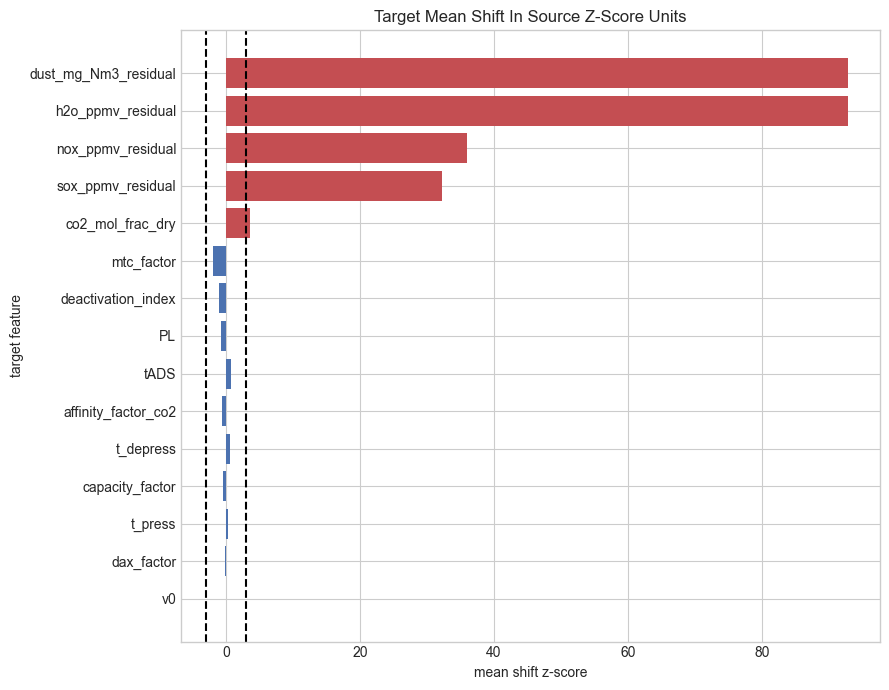

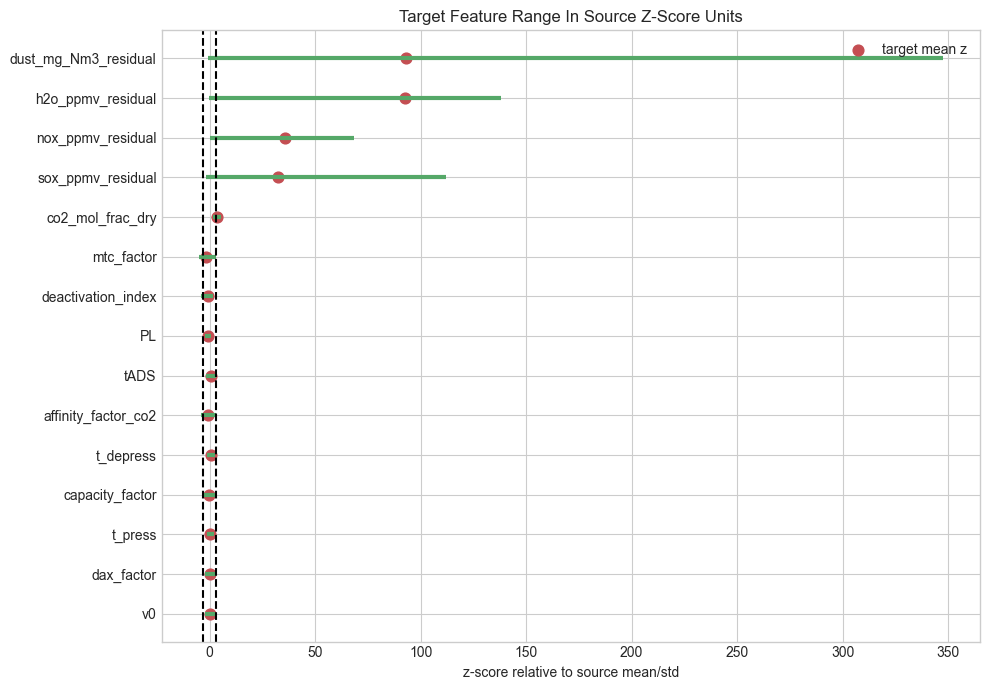

In [18]:
plot_distribution_shift(distribution_df)
plot_feature_range_shift(distribution_df)

## 8. Run Baselines And Improved Transfer Model

Compared models per target:

- `Mean Baseline`: predicts train-fold mean only
- `Target-only Ridge`: simple non-neural baseline
- `Target-only MLP`: small LIME-only neural baseline
- `Transfer + Adapter`: new transfer setup with train-fold target scaling, adapter, new head, and staged fine-tuning

In [19]:
results_by_target = {}
overall_rows = []

for target_col, model_name in TARGET_CONFIG.items():
    print("\n" + "=" * 100)
    print(f"Target: {target_col}")
    print("=" * 100)

    x_pool_raw = train_pool_df[TARGET_INPUT_COLS].to_numpy(dtype=np.float32)
    y_pool = train_pool_df[target_col].to_numpy(dtype=np.float32)
    x_test_raw = test_df[TARGET_INPUT_COLS].to_numpy(dtype=np.float32)
    y_test = test_df[target_col].to_numpy(dtype=np.float32)

    fold_rows = []
    best_payloads: dict[str, dict[str, object]] = {}
    best_val_by_model = {model_name_key: float("inf") for model_name_key in MODEL_LABELS}

    kfold = KFold(n_splits=5, shuffle=True, random_state=SEED)
    for fold_idx, (train_idx, val_idx) in enumerate(kfold.split(x_pool_raw), start=1):
        x_train_raw = x_pool_raw[train_idx]
        x_val_raw = x_pool_raw[val_idx]
        y_train = y_pool[train_idx]
        y_val = y_pool[val_idx]

        x_scaler = StandardScaler()
        x_train = x_scaler.fit_transform(x_train_raw)
        x_val = x_scaler.transform(x_val_raw)
        x_test = x_scaler.transform(x_test_raw)

        print(f"\nFold {fold_idx}/5")
        print(f"train rows: {len(train_idx)}, val rows: {len(val_idx)}, fixed test rows: {len(x_test)}")

        # Mean baseline.
        mean_value = float(np.mean(y_train))
        mean_val_pred = np.full(shape=len(y_val), fill_value=mean_value, dtype=np.float32)
        mean_test_pred = np.full(shape=len(y_test), fill_value=mean_value, dtype=np.float32)

        # Ridge baseline.
        ridge_model = Ridge(alpha=1.0)
        ridge_model.fit(x_train, y_train)
        ridge_val_pred = ridge_model.predict(x_val)
        ridge_test_pred = ridge_model.predict(x_test)

        # Target-only MLP.
        target_only_model, target_only_history = fit_target_only_model(x_train, y_train, x_val, y_val)
        target_only_val_pred = predict_with_model(target_only_model, x_val)
        target_only_test_pred = predict_with_model(target_only_model, x_test)

        # Improved transfer model.
        transfer_model, transfer_history = fit_transfer_model(
            model_path=MODEL_DIR / model_name,
            x_train=x_train,
            y_train=y_train,
            x_val=x_val,
            y_val=y_val,
        )
        transfer_val_pred = predict_with_model(transfer_model, x_val)
        transfer_test_pred = predict_with_model(transfer_model, x_test)

        fold_predictions = {
            "mean_baseline": (mean_val_pred, mean_test_pred, None),
            "ridge_baseline": (ridge_val_pred, ridge_test_pred, None),
            "target_only_mlp": (target_only_val_pred, target_only_test_pred, target_only_history),
            "transfer_model": (transfer_val_pred, transfer_test_pred, transfer_history),
        }

        for model_key, (val_pred, test_pred, history_payload) in fold_predictions.items():
            val_metrics = regression_metrics(y_val, np.clip(val_pred, 0.0, 1.0))
            test_metrics = regression_metrics(y_test, np.clip(test_pred, 0.0, 1.0))

            row = {
                "target": target_col,
                "model": model_key,
                "fold": fold_idx,
                "train_rows": len(train_idx),
                "val_rows": len(val_idx),
                "test_rows": len(y_test),
                "val_mae": val_metrics["mae"],
                "val_rmse": val_metrics["rmse"],
                "val_r2": val_metrics["r2"],
                "val_nmae": val_metrics["nmae_range"],
                "test_mae": test_metrics["mae"],
                "test_rmse": test_metrics["rmse"],
                "test_r2": test_metrics["r2"],
                "test_nmae": test_metrics["nmae_range"],
            }
            fold_rows.append(row)

            if val_metrics["mae"] < best_val_by_model[model_key]:
                best_val_by_model[model_key] = val_metrics["mae"]
                prediction_df = make_prediction_frame(test_df, target_col, np.clip(test_pred, 0.0, 1.0))
                best_payload = {
                    "fold_idx": fold_idx,
                    "val_metrics": val_metrics,
                    "test_metrics": test_metrics,
                    "prediction_df": prediction_df,
                    "history": history_payload,
                }

                if model_key in {"target_only_mlp", "transfer_model"}:
                    artifact_name = f"{target_col}_{model_key}_best_fold_{fold_idx}.keras"
                    if model_key == "target_only_mlp":
                        target_only_model.save(OUTPUT_DIR / artifact_name)
                        best_payload["model_path"] = OUTPUT_DIR / artifact_name
                    if model_key == "transfer_model":
                        transfer_model.save(OUTPUT_DIR / artifact_name)
                        best_payload["model_path"] = OUTPUT_DIR / artifact_name

                best_payloads[model_key] = best_payload

    fold_df = pd.DataFrame(fold_rows)
    summary_rows = []
    for model_key, group_df in fold_df.groupby("model"):
        summary_rows.append(
            {
                "model": model_key,
                "val_mae_mean": group_df["val_mae"].mean(),
                "val_mae_std": group_df["val_mae"].std(),
                "val_rmse_mean": group_df["val_rmse"].mean(),
                "val_rmse_std": group_df["val_rmse"].std(),
                "test_mae_mean": group_df["test_mae"].mean(),
                "test_mae_std": group_df["test_mae"].std(),
                "test_rmse_mean": group_df["test_rmse"].mean(),
                "test_rmse_std": group_df["test_rmse"].std(),
                "test_nmae_mean": group_df["test_nmae"].mean(),
                "test_nmae_std": group_df["test_nmae"].std(),
                "test_r2_mean": group_df["test_r2"].mean(),
                "test_r2_std": group_df["test_r2"].std(),
                "best_val_fold": best_payloads[model_key]["fold_idx"],
                "best_fold_test_mae": best_payloads[model_key]["test_metrics"]["mae"],
                "best_fold_test_rmse": best_payloads[model_key]["test_metrics"]["rmse"],
                "best_fold_test_nmae": best_payloads[model_key]["test_metrics"]["nmae_range"],
                "best_fold_test_r2": best_payloads[model_key]["test_metrics"]["r2"],
            }
        )

    summary_df = pd.DataFrame(summary_rows).sort_values("test_mae_mean").reset_index(drop=True)
    results_by_target[target_col] = {
        "fold_df": fold_df,
        "summary_df": summary_df,
        "best_payloads": best_payloads,
    }

    for _, row in summary_df.iterrows():
        overall_rows.append(
            {
                "target": target_col,
                "model": row["model"],
                "test_mae_mean": row["test_mae_mean"],
                "test_mae_std": row["test_mae_std"],
                "test_rmse_mean": row["test_rmse_mean"],
                "test_rmse_std": row["test_rmse_std"],
                "test_nmae_mean": row["test_nmae_mean"],
                "test_nmae_std": row["test_nmae_std"],
                "test_r2_mean": row["test_r2_mean"],
                "test_r2_std": row["test_r2_std"],
                "best_val_fold": row["best_val_fold"],
                "best_fold_test_mae": row["best_fold_test_mae"],
                "best_fold_test_rmse": row["best_fold_test_rmse"],
                "best_fold_test_nmae": row["best_fold_test_nmae"],
                "best_fold_test_r2": row["best_fold_test_r2"],
            }
        )

print("Training finished.")


Target: CO2_purity

Fold 1/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 2/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 3/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 4/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 5/5
train rows: 80, val rows: 20, fixed test rows: 10

Target: CO2_recovery

Fold 1/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 2/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 3/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 4/5
train rows: 80, val rows: 20, fixed test rows: 10

Fold 5/5
train rows: 80, val rows: 20, fixed test rows: 10
Training finished.


## 9. Fold Tables And Summary Tables

In [20]:
for target_col, result in results_by_target.items():
    print("\n" + "=" * 100)
    print(f"Fold metrics for {target_col}")
    print("=" * 100)
    display(result["fold_df"].sort_values(["model", "fold"]).reset_index(drop=True))

    print(f"\nSummary for {target_col}")
    display(result["summary_df"])

overall_summary_df = pd.DataFrame(overall_rows).sort_values(["target", "test_mae_mean"]).reset_index(drop=True)
print("\nOverall summary")
display(overall_summary_df)


Fold metrics for CO2_purity


,target,model,fold,train_rows,val_rows,test_rows,val_mae,val_rmse,val_r2,val_nmae,test_mae,test_rmse,test_r2,test_nmae
0,CO2_purity,mean_baseline,1,80,20,10,0.118891,0.137115,-0.000502,0.269271,0.092796,0.099657,-0.084081,0.339578
1,CO2_purity,mean_baseline,2,80,20,10,0.088430,0.105194,-0.035851,0.250642,0.093456,0.100626,-0.105261,0.341993
2,CO2_purity,mean_baseline,3,80,20,10,0.093004,0.110717,-0.262985,0.258453,0.090653,0.097219,-0.031677,0.331733
3,CO2_purity,mean_baseline,4,80,20,10,0.075565,0.090078,-0.044662,0.262215,0.093418,0.100568,-0.103984,0.341855
4,CO2_purity,mean_baseline,5,80,20,10,0.097094,0.113672,-0.006672,0.244408,0.093044,0.100009,-0.091740,0.340483
5,CO2_purity,ridge_baseline,1,80,20,10,0.038699,0.047801,0.878402,0.087647,0.032035,0.037322,0.847958,0.117228
6,CO2_purity,ridge_baseline,2,80,20,10,0.024343,0.031507,0.907074,0.068997,0.026942,0.033159,0.879983,0.098591
7,CO2_purity,ridge_baseline,3,80,20,10,0.023994,0.029089,0.912815,0.066678,0.030857,0.037339,0.847820,0.112918
8,CO2_purity,ridge_baseline,4,80,20,10,0.021206,0.025081,0.919009,0.073588,0.028997,0.034589,0.869410,0.106110
9,CO2_purity,ridge_baseline,5,80,20,10,0.031358,0.037944,0.887833,0.078936,0.028117,0.033834,0.875048,0.102893



Summary for CO2_purity


,model,val_mae_mean,val_mae_std,val_rmse_mean,val_rmse_std,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,test_nmae_mean,test_nmae_std,test_r2_mean,test_r2_std,best_val_fold,best_fold_test_mae,best_fold_test_rmse,best_fold_test_nmae,best_fold_test_r2
0,ridge_baseline,0.027920,0.007094,0.034285,0.008881,0.029390,0.002056,0.035248,0.001967,0.107548,0.007525,0.864044,0.015215,4,0.028997,0.034589,0.106110,0.869410
1,target_only_mlp,0.041885,0.005783,0.054824,0.008603,0.046370,0.009962,0.055050,0.012807,0.169687,0.036457,0.654886,0.161159,2,0.044028,0.050253,0.161116,0.724348
2,transfer_model,0.045544,0.019537,0.057972,0.021587,0.051529,0.022958,0.059533,0.023323,0.188564,0.084014,0.565638,0.368664,3,0.038231,0.045785,0.139903,0.771181
3,mean_baseline,0.094597,0.015805,0.111355,0.017029,0.092673,0.001162,0.099616,0.001399,0.339129,0.004253,-0.083349,0.030195,4,0.093418,0.100568,0.341855,-0.103984



Fold metrics for CO2_recovery


,target,model,fold,train_rows,val_rows,test_rows,val_mae,val_rmse,val_r2,val_nmae,test_mae,test_rmse,test_r2,test_nmae
0,CO2_recovery,mean_baseline,1,80,20,10,0.028401,0.035879,-0.242430,0.224949,0.028253,0.032050,-0.015614,0.265313
1,CO2_recovery,mean_baseline,2,80,20,10,0.025333,0.031723,-0.120942,0.231967,0.028253,0.033114,-0.084188,0.265313
2,CO2_recovery,mean_baseline,3,80,20,10,0.027686,0.033329,-0.000787,0.235283,0.028253,0.032637,-0.053130,0.265313
3,CO2_recovery,mean_baseline,4,80,20,10,0.022667,0.026727,-0.003327,0.242327,0.028253,0.032529,-0.046201,0.265313
4,CO2_recovery,mean_baseline,5,80,20,10,0.024334,0.030622,-0.040379,0.200430,0.028253,0.032881,-0.068939,0.265313
5,CO2_recovery,ridge_baseline,1,80,20,10,0.002178,0.003045,0.991049,0.017252,0.001447,0.001527,0.997695,0.013593
6,CO2_recovery,ridge_baseline,2,80,20,10,0.002022,0.002375,0.993717,0.018511,0.001980,0.002169,0.995348,0.018593
7,CO2_recovery,ridge_baseline,3,80,20,10,0.001829,0.002311,0.995189,0.015541,0.001758,0.001790,0.996832,0.016511
8,CO2_recovery,ridge_baseline,4,80,20,10,0.002218,0.004697,0.969008,0.023712,0.001186,0.001490,0.997805,0.011137
9,CO2_recovery,ridge_baseline,5,80,20,10,0.001606,0.002124,0.994997,0.013232,0.001714,0.001840,0.996653,0.016100



Summary for CO2_recovery


,model,val_mae_mean,val_mae_std,val_rmse_mean,val_rmse_std,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,test_nmae_mean,test_nmae_std,test_r2_mean,test_r2_std,best_val_fold,best_fold_test_mae,best_fold_test_rmse,best_fold_test_nmae,best_fold_test_r2
0,ridge_baseline,0.001971,0.000255,0.002910,0.001058,0.001617,0.000306,0.001763,0.000275,0.015187,0.002878,0.996867,0.000990,5,0.001714,0.001840,0.016100,0.996653
1,transfer_model,0.012189,0.002347,0.014819,0.002876,0.010873,0.002107,0.012823,0.001951,0.102105,0.019790,0.834415,0.051067,4,0.013455,0.015370,0.126351,0.766439
2,mean_baseline,0.025684,0.002368,0.031656,0.003391,0.028253,0.000000,0.032642,0.000401,0.265313,0.000000,-0.053614,0.025830,4,0.028253,0.032529,0.265313,-0.046201
3,target_only_mlp,0.032420,0.008384,0.039850,0.007643,0.043043,0.013586,0.049475,0.014827,0.404203,0.127580,-1.594089,1.527885,2,0.029266,0.032151,0.274828,-0.022010



Overall summary


,target,model,test_mae_mean,test_mae_std,test_rmse_mean,test_rmse_std,test_nmae_mean,test_nmae_std,test_r2_mean,test_r2_std,best_val_fold,best_fold_test_mae,best_fold_test_rmse,best_fold_test_nmae,best_fold_test_r2
0,CO2_purity,ridge_baseline,0.029390,0.002056,0.035248,0.001967,0.107548,0.007525,0.864044,0.015215,4,0.028997,0.034589,0.106110,0.869410
1,CO2_purity,target_only_mlp,0.046370,0.009962,0.055050,0.012807,0.169687,0.036457,0.654886,0.161159,2,0.044028,0.050253,0.161116,0.724348
2,CO2_purity,transfer_model,0.051529,0.022958,0.059533,0.023323,0.188564,0.084014,0.565638,0.368664,3,0.038231,0.045785,0.139903,0.771181
3,CO2_purity,mean_baseline,0.092673,0.001162,0.099616,0.001399,0.339129,0.004253,-0.083349,0.030195,4,0.093418,0.100568,0.341855,-0.103984
4,CO2_recovery,ridge_baseline,0.001617,0.000306,0.001763,0.000275,0.015187,0.002878,0.996867,0.000990,5,0.001714,0.001840,0.016100,0.996653
5,CO2_recovery,transfer_model,0.010873,0.002107,0.012823,0.001951,0.102105,0.019790,0.834415,0.051067,4,0.013455,0.015370,0.126351,0.766439
6,CO2_recovery,mean_baseline,0.028253,0.000000,0.032642,0.000401,0.265313,0.000000,-0.053614,0.025830,4,0.028253,0.032529,0.265313,-0.046201
7,CO2_recovery,target_only_mlp,0.043043,0.013586,0.049475,0.014827,0.404203,0.127580,-1.594089,1.527885,2,0.029266,0.032151,0.274828,-0.022010


## 10. Best-Fold Test Predictions

In [21]:
for target_col, result in results_by_target.items():
    print("\n" + "=" * 100)
    print(f"Best-fold test predictions for {target_col}")
    print("=" * 100)
    for model_key, payload in result["best_payloads"].items():
        print(f"\n{MODEL_LABELS[model_key]} | best val fold = {payload['fold_idx']}")
        print(pd.DataFrame([payload["test_metrics"]]).to_string(index=False))
        display(payload["prediction_df"])



Best-fold test predictions for CO2_purity

Mean Baseline | best val fold = 4
     mae     rmse        r2  nmae_range
0.093418 0.100568 -0.103984    0.341855


,sample_id,CO2_purity,pred_CO2_purity,error_CO2_purity
0,1,0.414882,0.474337,0.059455
1,2,0.331182,0.474337,0.143155
2,3,0.292858,0.474337,0.181478
3,4,0.552370,0.474337,-0.078033
4,5,0.394991,0.474337,0.079346
5,6,0.534615,0.474337,-0.060278
6,7,0.409832,0.474337,0.064505
7,8,0.380860,0.474337,0.093477
8,9,0.557004,0.474337,-0.082667
9,10,0.566128,0.474337,-0.091791



Target-only Ridge | best val fold = 4
     mae     rmse      r2  nmae_range
0.028997 0.034589 0.86941     0.10611


,sample_id,CO2_purity,pred_CO2_purity,error_CO2_purity
0,1,0.414882,0.412571,-0.002312
1,2,0.331182,0.353558,0.022376
2,3,0.292858,0.289997,-0.002862
3,4,0.552370,0.515455,-0.036915
4,5,0.394991,0.450463,0.055472
5,6,0.534615,0.595797,0.061182
6,7,0.409832,0.392086,-0.017745
7,8,0.380860,0.400456,0.019596
8,9,0.557004,0.523584,-0.033420
9,10,0.566128,0.528041,-0.038087



Target-only MLP | best val fold = 2
     mae     rmse       r2  nmae_range
0.044028 0.050253 0.724348    0.161116


...

,sample_id,CO2_recovery,pred_CO2_recovery,error_CO2_recovery
0,1,0.733736,0.735399,0.001663
1,2,0.727858,0.730665,0.002807
2,3,0.778197,0.779049,0.000851
3,4,0.743676,0.745730,0.002054
4,5,0.770993,0.769410,-0.001583
5,6,0.789477,0.787990,-0.001488
6,7,0.703328,0.704336,0.001007
7,8,0.748731,0.749692,0.000961
8,9,0.791373,0.789469,-0.001904
9,10,0.809817,0.806991,-0.002825



Target-only MLP | best val fold = 2
     mae     rmse       r2  nmae_range
0.029266 0.032151 -0.02201    0.274828


,sample_id,CO2_recovery,pred_CO2_recovery,error_CO2_recovery
0,1,0.733736,0.687879,-0.045857
1,2,0.727858,0.706572,-0.021287
2,3,0.778197,0.816297,0.038100
3,4,0.743676,0.756039,0.012363
4,5,0.770993,0.780519,0.009526
5,6,0.789477,0.759682,-0.029796
6,7,0.703328,0.680127,-0.023201
7,8,0.748731,0.801619,0.052887
8,9,0.791373,0.755081,-0.036292
9,10,0.809817,0.833166,0.023349



Transfer + Adapter | best val fold = 4
     mae    rmse       r2  nmae_range
0.013455 0.01537 0.766439    0.126351


,sample_id,CO2_recovery,pred_CO2_recovery,error_CO2_recovery
0,1,0.733736,0.706943,-0.026794
1,2,0.727858,0.752903,0.025045
2,3,0.778197,0.780762,0.002565
3,4,0.743676,0.755825,0.012149
4,5,0.770993,0.757337,-0.013656
5,6,0.789477,0.772070,-0.017407
6,7,0.703328,0.709156,0.005828
7,8,0.748731,0.756264,0.007532
8,9,0.791373,0.778022,-0.013351
9,10,0.809817,0.799595,-0.010222


## 11. Fold-Level Metric Plots

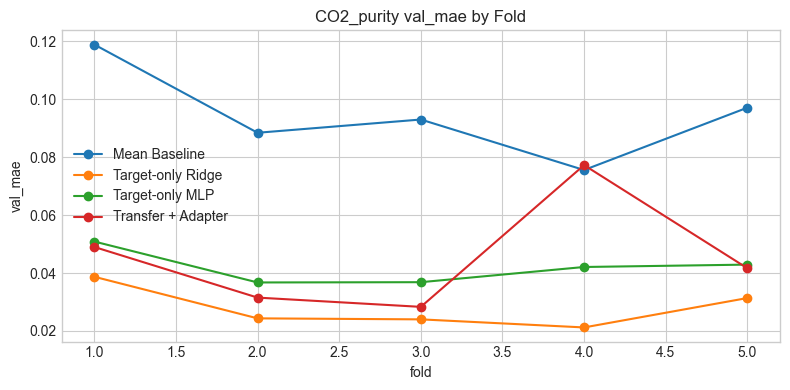

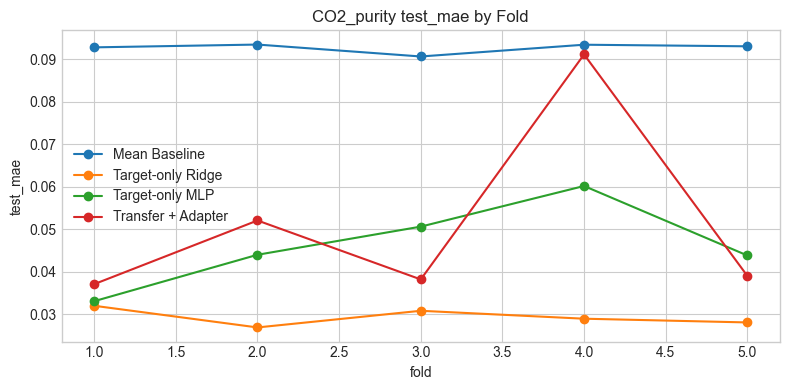

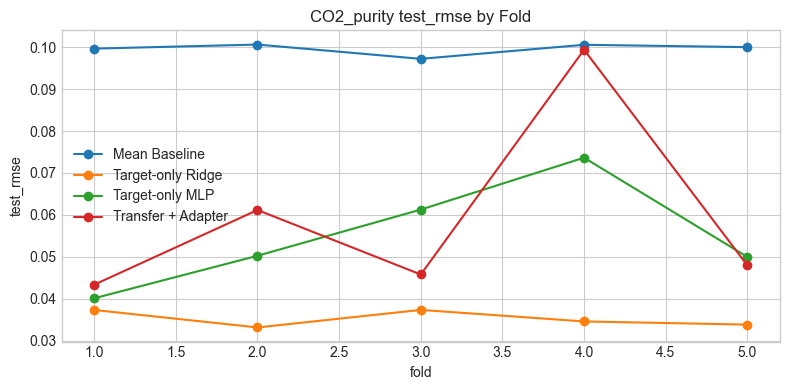

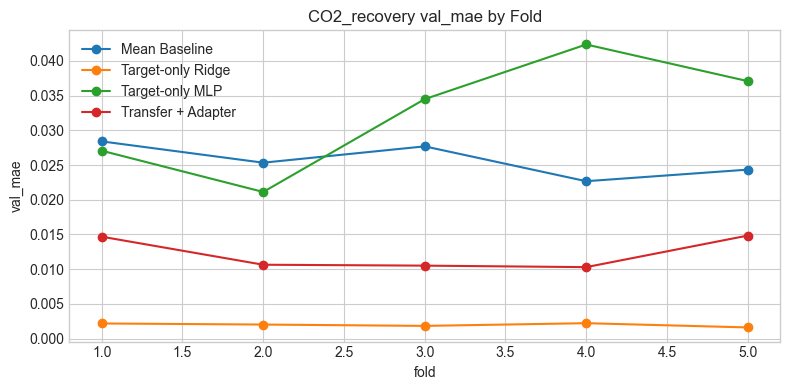

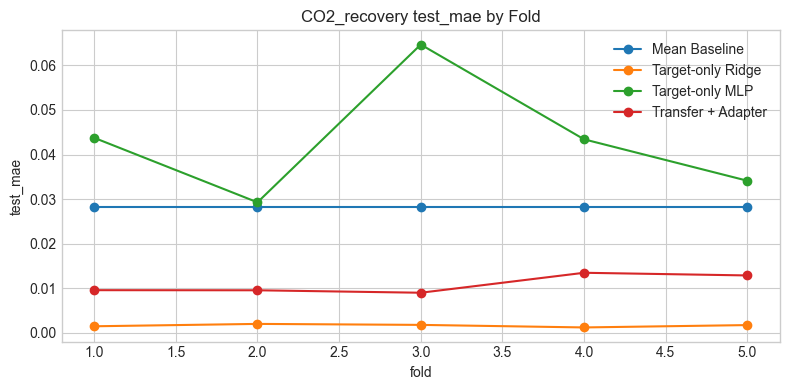

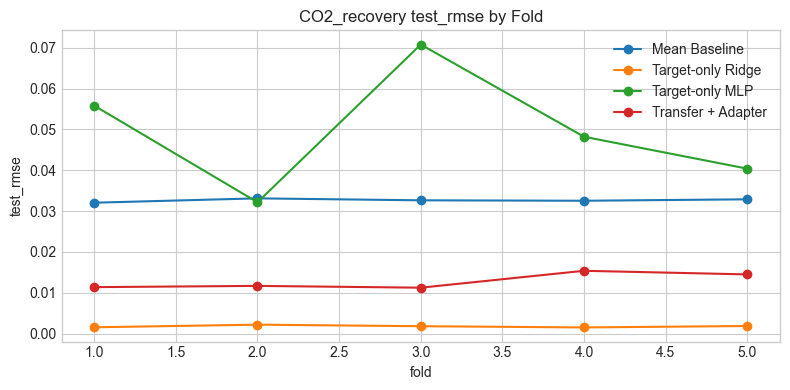

In [22]:
for target_col, result in results_by_target.items():
    plot_model_metric_by_fold(target_col, result["fold_df"], metric="val_mae")
    plot_model_metric_by_fold(target_col, result["fold_df"], metric="test_mae")
    plot_model_metric_by_fold(target_col, result["fold_df"], metric="test_rmse")


## 12. Test-Set Comparison Plots

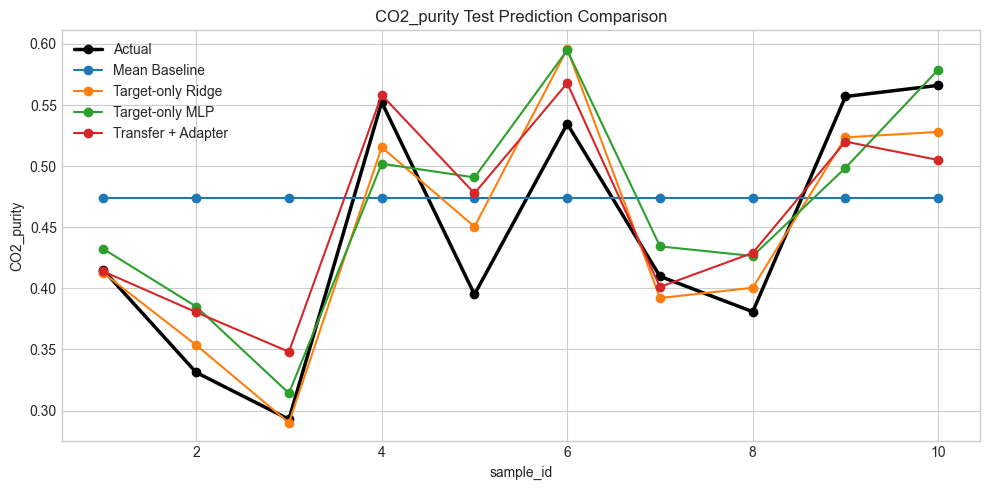

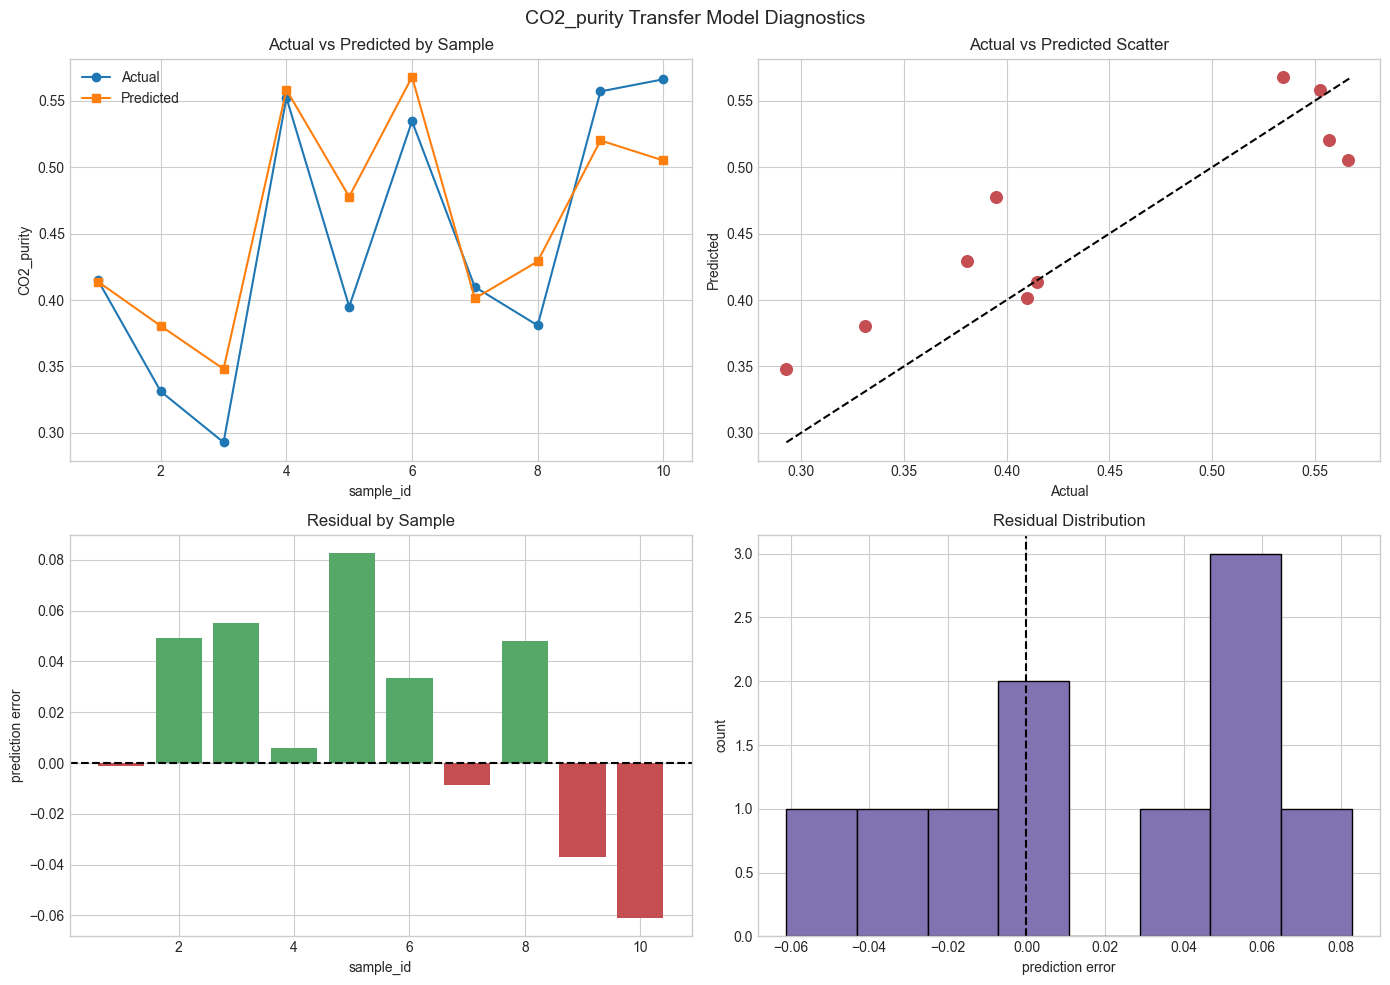

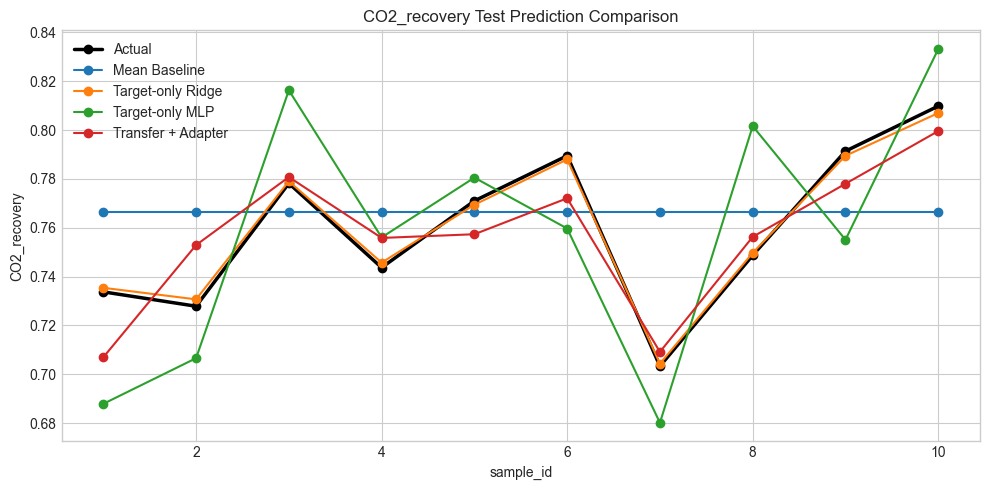

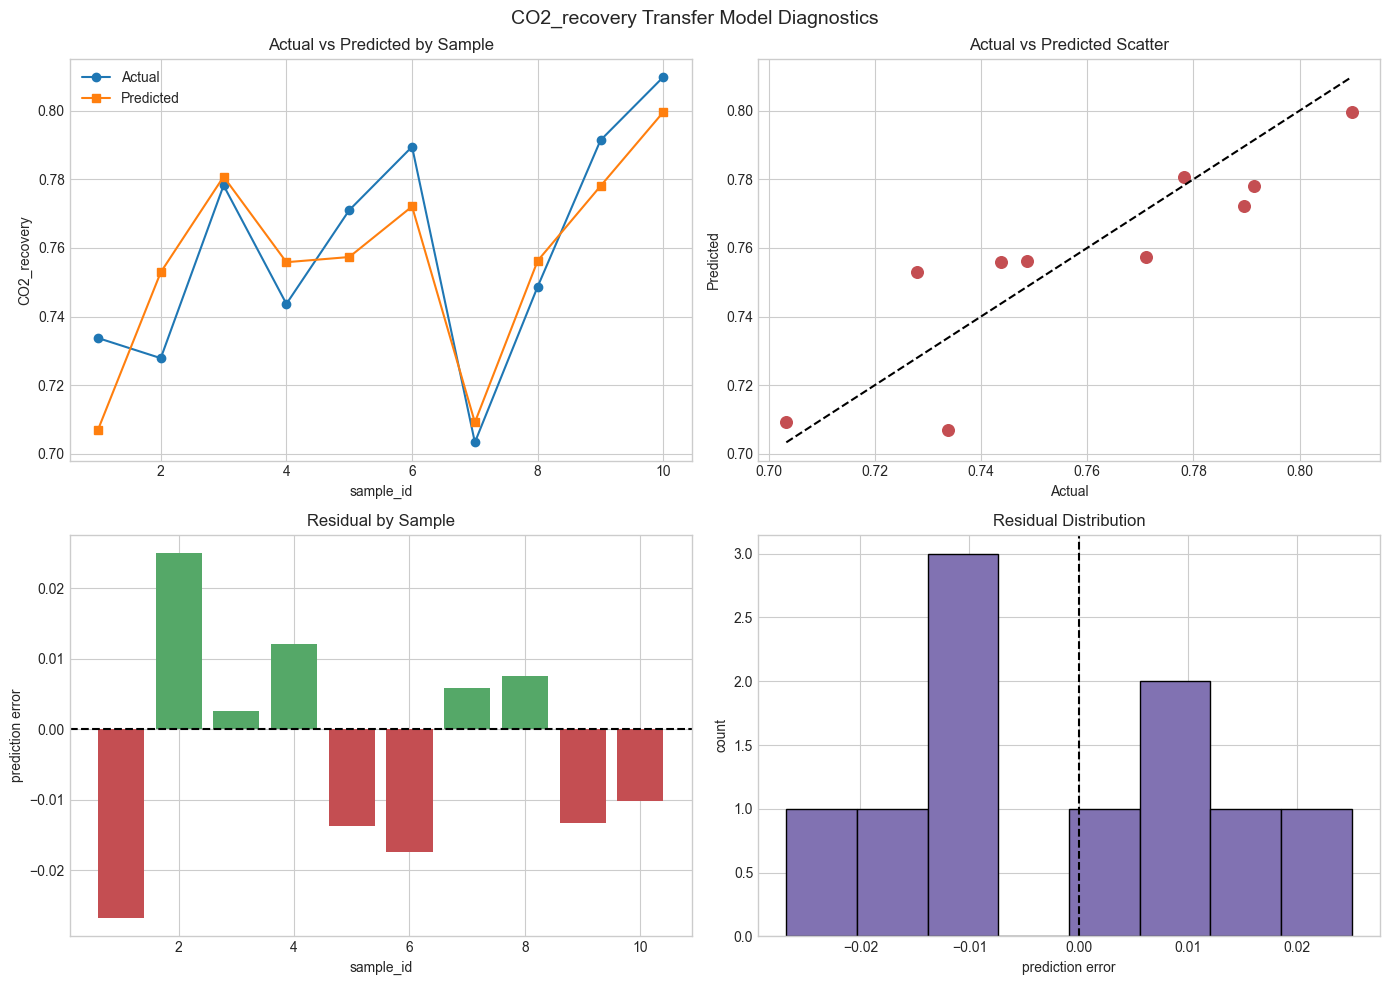

In [23]:
for target_col, result in results_by_target.items():
    plot_best_model_test_predictions(target_col, result["best_payloads"])
    plot_transfer_residuals(target_col, result["best_payloads"]["transfer_model"]["prediction_df"])


## 13. Learning Curves For Neural Models

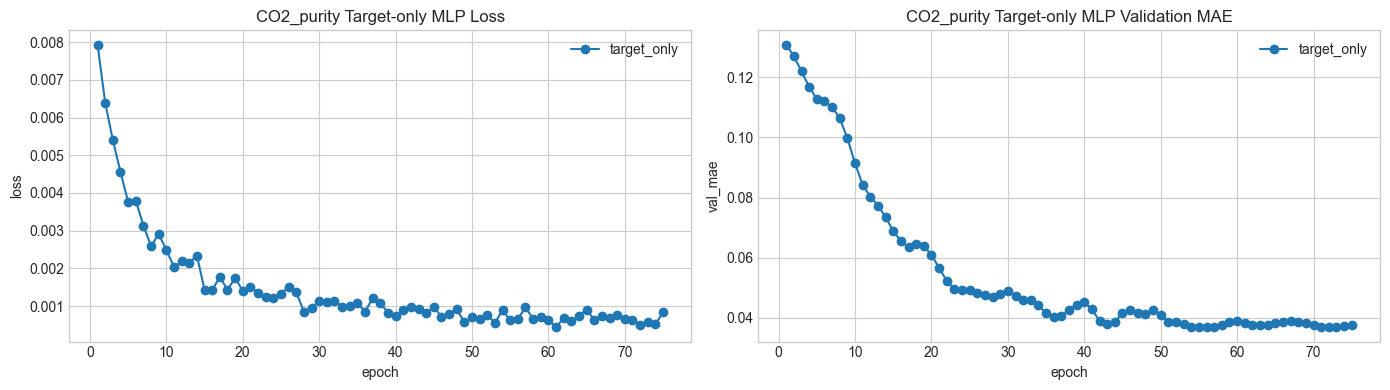

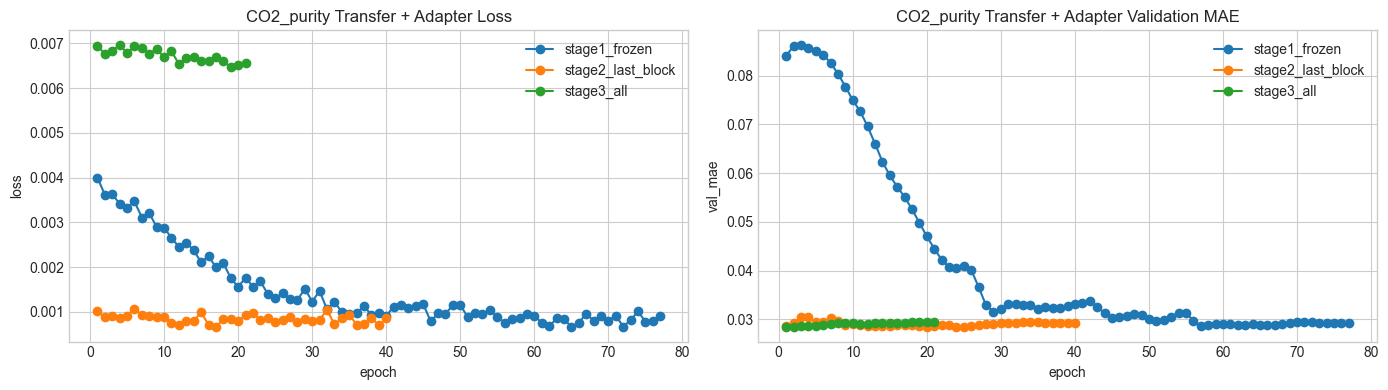

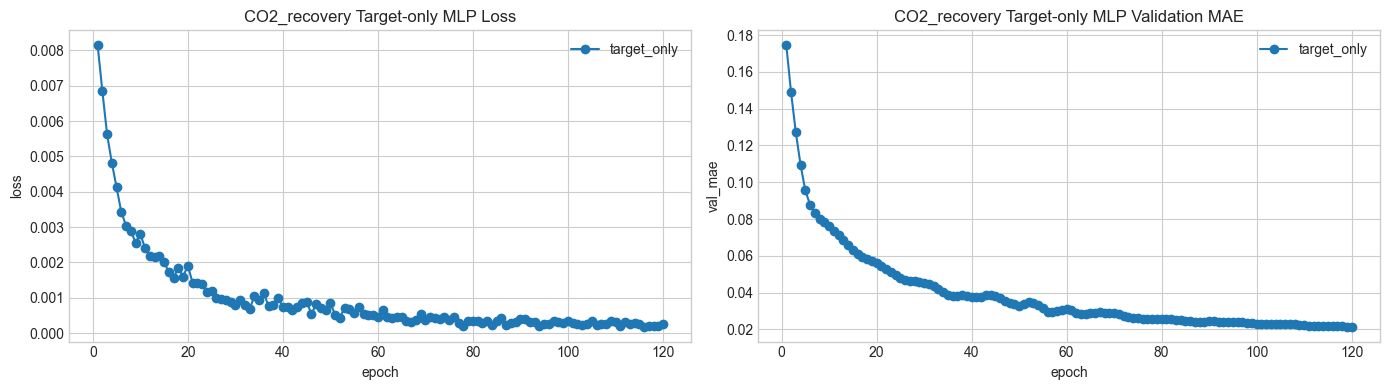

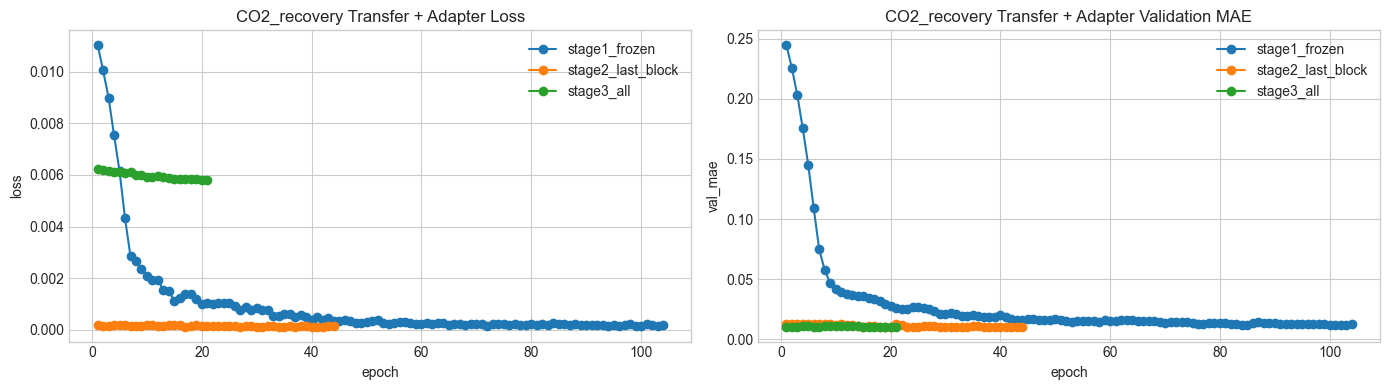

In [24]:
for target_col, result in results_by_target.items():
    best_payloads = result["best_payloads"]
    plot_learning_history(target_col, best_payloads["target_only_mlp"]["history"], model_label="Target-only MLP")
    plot_learning_history(target_col, best_payloads["transfer_model"]["history"], model_label="Transfer + Adapter")


## 14. Notes

- This notebook keeps the user-requested fixed test set `test_lime.csv`.
- Because the fixed test set has only 10 rows, use `MAE`, `RMSE`, and `NMAE` as primary signals.
- `R2` is still reported, but it can be unstable with very small test sets.
- The risky residual-style features are no longer treated as direct source features during training. Instead, the adapter learns how to map target-side inputs into the pretrained representation space.
- A multi-task model for purity and recovery is a reasonable next step, but this notebook first fixes the higher-priority issues in the original single-target transfer setup.